In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [101]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [102]:
# DATA SET PREPARED

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

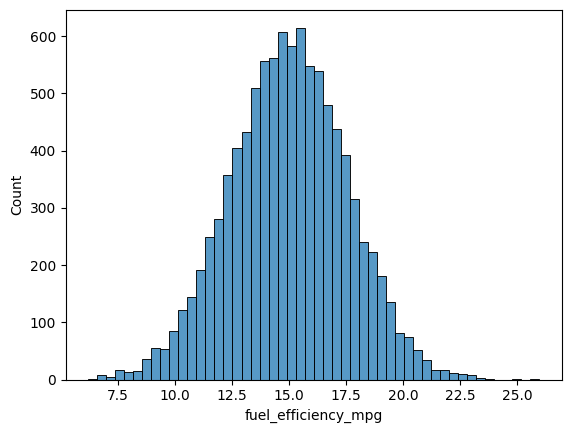

In [103]:
sns.histplot(df.fuel_efficiency_mpg, bins = 50)

In [104]:
# fuel efficiency graph created
# no long tail

In [105]:
# Q1
# Which column has missing values?
df.isnull().sum()
# Q1 answer = horsepower

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [106]:
# Q2
# What's the median for variable "horsepower"?
#df['horsepower'] = df['horsepower'].fillna(0)
np.nanmedian(df['horsepower'])
# Q2 answer = 149

np.float64(149.0)

In [107]:
np.nanmean(df['horsepower'])

np.float64(149.65729212983547)

In [108]:
# Splitting data set
#n = len(df)
#n_val = int(n * 0.2)
#n_test = int(n * 0.2)
#n_train = n - n_test - n_val

#idx = np.arange(n)

# data shuffle
#np.random.seed(42)
#np.random.shuffle(idx)

def split(df, seed):
    df = df.copy()

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_test - n_val
    
    idx = np.arange(n)
    
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    # splitting data sets
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    # reorder data sets
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    # create target lists
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    # delete targets out of data sets
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [109]:
# Q3
# Which option of filling null values gives a better RMSE?

df_train, df_val, df_test, y_train, y_val, y_test = split(df, 42)

# linear regression funciton
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

df_train_zero = df_train.copy()
df_train_mean = df_train.copy()

df_val_zero = df_val.copy()
df_val_mean = df_val.copy()

# fill all nulls with 0
#df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
#df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

# fill all nulls with the median
#df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(149.66)
#df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(149.66)

# RMSE function
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

def prepare_X(df, fill):
    df_num = df[base]
    df_num = df_num.fillna(fill)
    X = df_num.values
    return X

In [110]:
X_train_zero = prepare_X(df_train, 0)
w0_1, w_1 = train_linear_regression(X_train_zero, y_train)

X_train_mean = prepare_X(df_train, 149.66)
w0_2, w_2 = train_linear_regression(X_train_median, y_train)

X_val_zero = prepare_X(df_val_zero, 0)
X_val_mean = prepare_X(df_val_mean, 149.66)

y_pred_zero = w0_1 + X_val_zero.dot(w_1)
y_pred_mean = w0_2 + X_val_mean.dot(w_2)

In [111]:
# Zero fill RMSE
rmse(y_val, y_pred_zero)

np.float64(0.5173782638841185)

In [112]:
# Median fill RMSE
rmse(y_val, y_pred_median)

np.float64(0.4635725479433808)

In [113]:
# answer Q3 = with mean

In [114]:
# Q4
# Train regularize linear regression. Determine best value of r.
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [115]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)
    y_pred = w0 + X_val_zero.dot(w)
    print('%6s' % r, rmse(y_val, y_pred))

# answer Q4 = 0.01 gives the smallest rmse value

     0 0.5173782638841185
  0.01 0.5171115525775559
   0.1 0.5187525130701629
     1 0.5222348802092528
     5 0.5228916092823455
    10 0.5229812979636569
   100 0.5230636233819926


In [124]:
# Q5
# Try different seeds. Find the standard deviation of the different scores.
rmse_values = []

for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split(df, i)

    X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, 0)
    y_pred = w0 + X_val.dot(w)
    
    rmse_value = rmse(y_val, y_pred)
    rmse_values.append(rmse_value)
    
    print('Seed', i, ':', rmse_value) 

Seed 0 : 0.5206531296297207
Seed 1 : 0.5213388912866506
Seed 2 : 0.5228069974913666
Seed 3 : 0.5159516741255491
Seed 4 : 0.5109129460116937
Seed 5 : 0.5283406460212935
Seed 6 : 0.5313910658190373
Seed 7 : 0.509067038739038
Seed 8 : 0.5147399129482789
Seed 9 : 0.513186590829269


In [127]:
standard_deviation = np.std(rmse_values)
standard_deviation
# answer Q5 = 0.006

np.float64(0.006989446427824928)

In [131]:
# Q6
# Find RMSE with combined train and val datasets.

df_train, df_val, df_test, y_train, y_val, y_test = split(df, 9)

df_full = pd.concat([df_train, df_val])
df_full = df_full.reset_index(drop=True)
X_full = prepare_X(df_full, 0)
y_full = np.concat([y_train, y_val])

w0, w = train_linear_regression_reg(X_full, y_full, r=0.001)
X_test = prepare_X(df_test, 0)
y_pred = w0 + X_test.dot(w)

print('final:', rmse(y_test, y_pred))

# answer Q6 = 0.515

final: 0.5156261299185628
